In [85]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings('ignore')

# Reload modules if running in an existing kernel
import importlib
import sys

# Deep reload of utils module and its submodules
modules_to_reload = [m for m in sys.modules.keys() if m.startswith('utils')]
for module_name in modules_to_reload:
    if module_name in sys.modules:
        del sys.modules[module_name]

# Import our custom utilities
from reachgrasp import(
    load_joint_angles_with_labels,
    get_joint_groups,
    get_arm_joints,
    get_hand_joints,
    get_region_colors,
    get_component_colors,
    calculate_velocity,
    calculate_acceleration,
    calculate_movement_smoothness,
    detect_movement_onset,
    find_highly_correlated_pairs,
    calculate_channel_statistics
)

print("Libraries imported successfully")
print(f"Working directory: {os.getcwd()}")

Libraries imported successfully
Working directory: /home/bmaacaron-iit.local/Documents/Datasets/ReachGrasp


In [86]:
# Global Configuration Variables
# Choose subject and action for analysis

# Available subjects: sub-01 through sub-10
SELECTED_SUBJECT = 'sub-01'

# Available actions/tasks:
# Cyl (Cylindrical grasp), EatFruit, FroRea (Forward reach), HC (Hand close),
# HO (Hand open), Pour, ReaCyl (Reach cylindrical), ReaSph (Reach spherical),
# Screw, Sph (Spherical grasp), Thumb, Trid (Triangular grasp), WE, WF, WP, WS
SELECTED_ACTION = 'Pour'  # Example: 'FroRea' for Forward reach

# Joint selection filter:
# 'all'    - Analyze all joints (arm + hand)
# 'arm'    - Analyze only arm joints (Thorax, Shoulder, Elbow, Wrist)
# 'hand'   - Analyze only hand joints (Fingers, Thumb)
# ['joint1', 'joint2', ...] - Custom list of specific joints
JOINT_FILTER = 'arm'  # Options: 'all', 'arm', 'hand', or list of joint names

# Visualization options
SHOW_CUT_MARKERS = True  # Set to True to display repetition boundaries on plots

print("Joint Data Analysis Configuration:")
print(f"Subject: {SELECTED_SUBJECT}")
print(f"Action: {SELECTED_ACTION}")
print(f"Joint Filter: {JOINT_FILTER}")
print(f"Show Cut Markers: {SHOW_CUT_MARKERS}")
print(f"Data path: {SELECTED_SUBJECT}/motion/{SELECTED_SUBJECT}_task-{SELECTED_ACTION}_acq-vicon_motion.csv")

Joint Data Analysis Configuration:
Subject: sub-01
Action: Pour
Joint Filter: arm
Show Cut Markers: True
Data path: sub-01/motion/sub-01_task-Pour_acq-vicon_motion.csv


# Joint Kinematics Analysis - ReachGrasp Dataset

This notebook provides specialized analysis of joint kinematics data from the ReachGrasp dataset. We focus on:

1. **Joint Angle Trajectories**: Time-series analysis of individual joint movements
2. **Movement Coordination**: Relationships between different joints during tasks
3. **Kinematic Patterns**: Identification of movement phases and coordination strategies
4. **Comparative Analysis**: Cross-task and cross-subject joint behavior

## Data Source
- **Motion Capture System**: Vicon optical system (100 Hz sampling)
- **Joint Representation**: 31 joint angles capturing full upper limb kinematics
- **Coordinate System**: Anatomical joint angles in degrees

## Analysis Configuration
- **Subject**: Configurable via `SELECTED_SUBJECT` variable
- **Action**: Configurable via `SELECTED_ACTION` variable
- **Focus**: Pure joint kinematics without EMG or tactile data

## Data Loading

Load and structure the joint kinematics data with anatomical grouping for better visualization and analysis.

**Data Organization:**
- Joint channels are named with anatomical region + XYZ component (e.g., `RElbow_X`, `RWrist_Y`)
- Joints are grouped by anatomical regions: Thorax, Shoulder, Elbow, Wrist, Fingers (Index, Middle, Ring, Pinky), Thumb
- XYZ components represent different movement types:
  - **X**: Primary flexion/extension
  - **Y**: Secondary movements (abduction/adduction)  
  - **Z**: Rotational movements

**Joint Filtering:**
Use `JOINT_FILTER` variable to focus analysis on specific joint groups:
- **'all'** - Analyze all 31 joints (complete upper limb)
- **'arm'** - Analyze only arm joints: Thorax (Left/Right), Shoulder, Elbow, Wrist (15 joints)
- **'hand'** - Analyze only hand joints: Fingers (Index/Middle/Ring/Pinky), Thumb (16 joints)
- **Custom list** - Specify exact joints: `['RElbow_X', 'RWrist_Y', 'RIndex_X']`

### Quick Joint Filter Examples

To analyze only arm movements (proximal joints + wrist):
```python
JOINT_FILTER = 'arm'  # Thorax, Shoulder, Elbow, Wrist → 15 joints
```

To analyze only hand movements (distal joints):
```python
JOINT_FILTER = 'hand'  # Fingers (Index/Middle/Ring/Pinky), Thumb → 16 joints
```

To analyze the complete upper limb:
```python
JOINT_FILTER = 'all'  # All joints → 31 joints
```

To analyze custom joints:
```python
JOINT_FILTER = ['RElbow_X', 'RWrist_Y', 'RIndex_X']  # Specific joints of interest
```

**Note:** After changing `JOINT_FILTER`, re-run cells from the "Data Loading" section onward.

In [87]:
# Quick test of different filter modes
print("Joint Filter Modes Summary:")
print("=" * 70)
print()

# Get all joint groups
all_groups = get_joint_groups()

# Get arm and hand joints using utility functions
arm_joints = get_arm_joints()
hand_joints = get_hand_joints()

# Define arm regions (including Wrist)
arm_regions = ['Thorax_Left', 'Thorax_Right', 'Shoulder', 'Elbow', 'Wrist']

# Define hand regions  
hand_regions = ['Index', 'Middle', 'Ring', 'Pinky', 'Thumb_STT', 'Thumb_MCP']

print(f"ARM MODE (JOINT_FILTER='arm'):")
print(f"  Regions: {', '.join(arm_regions)}")
print(f"  Total joints: {len(arm_joints)}")
print(f"  Joints: {', '.join(arm_joints[:5])}...")
print()

print(f"HAND MODE (JOINT_FILTER='hand'):")
print(f"  Regions: {', '.join(hand_regions)}")
print(f"  Total joints: {len(hand_joints)}")
print(f"  Joints: {', '.join(hand_joints[:5])}...")
print()

print(f"ALL MODE (JOINT_FILTER='all'):")
print(f"  Regions: All {len(all_groups)} regions")
print(f"  Total joints: {len(arm_joints) + len(hand_joints)}")
print()

print(f"CUSTOM MODE (JOINT_FILTER=['RElbow_X', 'RWrist_Y', ...]):")
print(f"  Specify any combination of joints")
print(f"  Example: ['RElbow_X', 'RWrist_Y', 'RIndex_X']")
print()

print(f"Current setting: JOINT_FILTER = {JOINT_FILTER!r}")

Joint Filter Modes Summary:

ARM MODE (JOINT_FILTER='arm'):
  Regions: Thorax_Left, Thorax_Right, Shoulder, Elbow, Wrist
  Total joints: 15
  Joints: LThorax_X, LThorax_Y, LThorax_Z, RThorax_X, RThorax_Y...

HAND MODE (JOINT_FILTER='hand'):
  Regions: Index, Middle, Ring, Pinky, Thumb_STT, Thumb_MCP
  Total joints: 16
  Joints: RIndex_X, RIndex_Y, RIndex_Z, RMiddle_X, RMiddle_Y...

ALL MODE (JOINT_FILTER='all'):
  Regions: All 11 regions
  Total joints: 31

CUSTOM MODE (JOINT_FILTER=['RElbow_X', 'RWrist_Y', ...]):
  Specify any combination of joints
  Example: ['RElbow_X', 'RWrist_Y', 'RIndex_X']

Current setting: JOINT_FILTER = 'arm'


In [88]:
# Test custom joint filter mode
print("Testing Custom Joint Selection:")
print("=" * 70)

# Example 1: Flexion chain (X components from elbow to finger)
custom_joints_1 = ['RElbow_X', 'RWrist_X', 'RIndex_X', 'RMiddle_X']
print(f"\nExample 1 - Flexion chain:")
print(f"  Joints: {custom_joints_1}")
print(f"  Count: {len(custom_joints_1)}")

# Example 2: Wrist and first finger
custom_joints_2 = ['RWrist_X', 'RWrist_Y', 'RWrist_Z', 'RIndex_X', 'RIndex_Y', 'RIndex_Z']
print(f"\nExample 2 - Wrist + Index finger (all components):")
print(f"  Joints: {custom_joints_2}")
print(f"  Count: {len(custom_joints_2)}")

# Example 3: All Y components (abduction/adduction)
all_joints_full = list(get_joint_groups().values())
all_joint_names = sum(all_joints_full, [])
custom_joints_3 = [j for j in all_joint_names if j.endswith('_Y')]
print(f"\nExample 3 - All Y-components (abduction/adduction):")
print(f"  Joints: {custom_joints_3[:5]}... ({len(custom_joints_3)} total)")
print(f"  Count: {len(custom_joints_3)}")

print(f"\nTo use custom selection, set:")
print(f"JOINT_FILTER = {custom_joints_1}")
print(f"\nThen re-run from 'Data Loading' section")

Testing Custom Joint Selection:

Example 1 - Flexion chain:
  Joints: ['RElbow_X', 'RWrist_X', 'RIndex_X', 'RMiddle_X']
  Count: 4

Example 2 - Wrist + Index finger (all components):
  Joints: ['RWrist_X', 'RWrist_Y', 'RWrist_Z', 'RIndex_X', 'RIndex_Y', 'RIndex_Z']
  Count: 6

Example 3 - All Y-components (abduction/adduction):
  Joints: ['LThorax_Y', 'RThorax_Y', 'RShoulder_Y', 'RElbow_Y', 'RWrist_Y']... (10 total)
  Count: 10

To use custom selection, set:
JOINT_FILTER = ['RElbow_X', 'RWrist_X', 'RIndex_X', 'RMiddle_X']

Then re-run from 'Data Loading' section


In [89]:
# Test loading with custom joint list
print("Testing data loading with custom joint list:")
print("=" * 70)

# Save current filter
original_filter = JOINT_FILTER

# Test with custom list
test_custom_joints = ['RElbow_X', 'RWrist_X', 'RIndex_X', 'RMiddle_X']
JOINT_FILTER = test_custom_joints

try:
    # Load data with custom filter
    time_test, joint_angles_test_full = load_joint_angles_with_labels(
        SELECTED_SUBJECT, SELECTED_ACTION, acquisition='vicon'
    )
    
    joint_groups_test_full = get_joint_groups()
    
    # Apply custom filter
    selected_joints = JOINT_FILTER
    joint_angles_test = joint_angles_test_full[selected_joints]
    
    # Build joint_groups based on selected joints
    joint_groups_test = {}
    for region_name, region_joints in joint_groups_test_full.items():
        region_selected = [j for j in region_joints if j in selected_joints]
        if region_selected:
            joint_groups_test[region_name] = region_selected
    
    print(f"✓ Successfully loaded with custom joint list")
    print(f"  Custom joints: {test_custom_joints}")
    print(f"  Loaded shape: {joint_angles_test.shape}")
    print(f"  Columns: {list(joint_angles_test.columns)}")
    print(f"  Regions covered: {list(joint_groups_test.keys())}")
    
except Exception as e:
    print(f"✗ Error: {e}")

# Restore original filter
JOINT_FILTER = original_filter
print(f"\n✓ Filter restored to: {JOINT_FILTER}")

Testing data loading with custom joint list:
Split data into 10 movements
✗ Error: too many values to unpack (expected 2)

✓ Filter restored to: arm


In [90]:
# Load joint kinematics data using utility functions
try:
    # Use utility function to load data with anatomical labels
    time, joint_angles_full = load_joint_angles_with_labels(
        SELECTED_SUBJECT, 
        SELECTED_ACTION, 
        acquisition='vicon',
        split_repetitions=False  # Load continuous recording for plotting with cuts
    )
    
    # Get anatomical grouping and color schemes
    joint_groups_full = get_joint_groups()
    region_colors = get_region_colors()
    component_colors = get_component_colors()
    
    # Apply joint filter based on JOINT_FILTER setting
    if isinstance(JOINT_FILTER, list):
        # Custom joint list provided
        selected_joints = JOINT_FILTER
        # Validate that all joints exist
        invalid_joints = [j for j in selected_joints if j not in joint_angles_full.columns]
        if invalid_joints:
            print(f"WARNING: Invalid joints specified: {invalid_joints}")
            print(f"Available joints: {list(joint_angles_full.columns)}")
            raise ValueError(f"Invalid joints in JOINT_FILTER: {invalid_joints}")
        
        joint_angles = joint_angles_full[selected_joints]
        
        # Build joint_groups based on selected joints
        joint_groups = {}
        for region_name, region_joints in joint_groups_full.items():
            region_selected = [j for j in region_joints if j in selected_joints]
            if region_selected:
                joint_groups[region_name] = region_selected
        
        filter_desc = f"CUSTOM JOINTS ({len(selected_joints)} selected)"
        
    elif JOINT_FILTER == 'arm':
        # Arm joints: Thorax, Shoulder, Elbow, Wrist
        selected_joints = get_arm_joints()
        arm_regions = ['Thorax_Left', 'Thorax_Right', 'Shoulder', 'Elbow', 'Wrist']
        joint_groups = {region: joint_groups_full[region] for region in arm_regions}
        joint_angles = joint_angles_full[selected_joints]
        filter_desc = "ARM JOINTS (Thorax, Shoulder, Elbow, Wrist)"
        
    elif JOINT_FILTER == 'hand':
        # Hand joints: Fingers, Thumb
        selected_joints = get_hand_joints()
        hand_regions = ['Index', 'Middle', 'Ring', 'Pinky', 'Thumb_STT', 'Thumb_MCP']
        joint_groups = {region: joint_groups_full[region] for region in hand_regions}
        joint_angles = joint_angles_full[selected_joints]
        filter_desc = "HAND JOINTS (Fingers, Thumb)"
        
    else:  # 'all' or any other value
        joint_angles = joint_angles_full
        joint_groups = joint_groups_full
        filter_desc = "ALL JOINTS (Arm + Hand)"

    print("Joint kinematics data loaded successfully")
    print(f"Filter: {filter_desc}")
    print(f"Duration: {time[-1]:.2f} seconds")
    print(f"Sampling rate: 100 Hz")
    print(f"Number of joints: {joint_angles.shape[1]} (of {joint_angles_full.shape[1]} total)")
    print(f"Joint angles range: [{joint_angles.min().min():.1f}°, {joint_angles.max().max():.1f}°]")
    print(f"\nSelected anatomical regions: {list(joint_groups.keys())}")
    print(f"Columns: {list(joint_angles.columns[:5])}...")  # Show first 5 column names
    
    # Load time cut indices if cut markers are enabled
    if SHOW_CUT_MARKERS:
        from utils.data_loading import load_time_cuts, get_task_time_cuts, convert_cut_indices_to_times
        time_cuts_data = load_time_cuts()
        cut_indices = get_task_time_cuts(time_cuts_data, SELECTED_SUBJECT, SELECTED_ACTION)
        
        if cut_indices:
            # Convert indices to time values for display
            cut_times = convert_cut_indices_to_times(time, cut_indices)
            print(f"\n✓ Loaded time cuts: {len(cut_indices)//2} repetitions")
            duration_first = cut_times[1] - cut_times[0]
            print(f"  First repetition: {cut_times[0]:.2f}s - {cut_times[1]:.2f}s (duration: {duration_first:.2f}s)")
        else:
            print("\n⚠ Warning: Could not load time cuts for this subject/action")
            cut_indices = None
    else:
        cut_indices = None
        print("\n(Cut markers disabled)")
    
except FileNotFoundError as e:
    print(f"Error: {e}")
    print("Please check that the subject and action variables are set correctly.")
    print("Available subjects: sub-01 through sub-10")
    print("Available actions: Cyl, EatFruit, FroRea, HC, HO, Pour, ReaCyl, ReaSph, Screw, Sph, Thumb, Trid, WE, WF, WP, WS")
    cut_indices = None
except ValueError as e:
    print(f"Error: {e}")
    cut_indices = None

Joint kinematics data loaded successfully
Filter: ARM JOINTS (Thorax, Shoulder, Elbow, Wrist)
Duration: 88.15 seconds
Sampling rate: 100 Hz
Number of joints: 15 (of 31 total)
Joint angles range: [-16.4°, 191.7°]

Selected anatomical regions: ['Thorax_Left', 'Thorax_Right', 'Shoulder', 'Elbow', 'Wrist']
Columns: ['LThorax_X', 'LThorax_Y', 'LThorax_Z', 'RThorax_X', 'RThorax_Y']...

✓ Loaded time cuts: 11 repetitions
  First repetition: 4.56s - 6.81s (duration: 2.25s)


### Repetition Boundaries

When `SHOW_CUT_MARKERS = True`, repetition boundaries are overlaid on plots:
- **Green dashed lines** mark the start of each repetition
- **Red dotted lines** mark the end of each repetition

This helps identify movement phases and temporal structure within the recording.

In [91]:
# Display detailed time cut information
if SHOW_CUT_MARKERS and cut_indices is not None:
    from utils.data_loading import convert_cut_indices_to_times
    
    print("Repetition Timing Information:")
    print("=" * 70)
    print(f"Total recording duration: {time[-1]:.2f}s")
    print(f"Number of repetitions: {len(cut_indices)//2}")
    print(f"\nRepetition boundaries:")
    
    # Convert indices to time values
    cut_times = convert_cut_indices_to_times(time, cut_indices)
    
    for i in range(0, len(cut_times), 2):
        rep_num = i // 2 + 1
        start_time = cut_times[i]
        end_time = cut_times[i + 1]
        duration = end_time - start_time
        print(f"  Rep {rep_num:2d}: {start_time:6.2f}s - {end_time:6.2f}s (duration: {duration:5.2f}s)")
    
    # Summary statistics
    durations = [cut_times[i+1] - cut_times[i] for i in range(0, len(cut_times), 2)]
    print()
    print(f"Movement duration: Mean={np.mean(durations):.2f}s, "
          f"Std={np.std(durations):.2f}s, "
          f"Range=[{np.min(durations):.2f}s, {np.max(durations):.2f}s]")
    
    # Calculate rest periods
    if len(cut_times) >= 4:
        rests = [cut_times[i+2] - cut_times[i+1] for i in range(0, len(cut_times)-2, 2)]
        print(f"Rest periods: Mean={np.mean(rests):.2f}s, "
              f"Std={np.std(rests):.2f}s, "
              f"Range=[{np.min(rests):.2f}s, {np.max(rests):.2f}s]")
else:
    print("Time cut markers are disabled. Set SHOW_CUT_MARKERS = True to enable.")

Repetition Timing Information:
Total recording duration: 88.15s
Number of repetitions: 11

Repetition boundaries:
  Rep  1:   4.56s -   6.81s (duration:  2.25s)
  Rep  2:  13.61s -  15.77s (duration:  2.16s)
  Rep  3:  21.07s -  23.43s (duration:  2.36s)
  Rep  4:  28.45s -  30.58s (duration:  2.13s)
  Rep  5:  35.54s -  37.90s (duration:  2.36s)
  Rep  6:  42.72s -  45.57s (duration:  2.85s)
  Rep  7:  50.14s -  53.03s (duration:  2.89s)
  Rep  8:  57.84s -  61.00s (duration:  3.16s)
  Rep  9:  65.93s -  69.80s (duration:  3.87s)
  Rep 10:  74.56s -  77.81s (duration:  3.25s)
  Rep 11:  82.19s -  85.49s (duration:  3.30s)

Movement duration: Mean=2.78s, Std=0.55s, Range=[2.13s, 3.87s]
Rest periods: Mean=5.04s, Std=0.63s, Range=[4.38s, 6.80s]


## Joint Data Overview

Explore the basic characteristics of the joint angle data.

In [92]:
# Calculate comprehensive statistics using utility function
print("Joint Angle Statistics by Anatomical Region:")
print("=" * 70)

# Use utility function for statistics
joint_stats = calculate_channel_statistics(joint_angles)

# Display statistics grouped by anatomical region
for region_name, joint_cols in joint_groups.items():
    print(f"\n{region_name.upper().replace('_', ' ')}:")
    print(f"{'Channel':<20} {'Mean':>8} {'Std':>8} {'Range':>8} {'RMS':>8}")
    print("-" * 66)
    
    for col in joint_cols:
        stats = joint_stats.loc[col]
        print(f"{col:<20} {stats['Mean']:>8.1f} {stats['Std']:>8.1f} "
              f"{stats['Range']:>8.1f} {stats['RMS']:>8.1f}")

print(f"\n{'='*70}")
print("OVERALL STATISTICS:")
print(f"{'='*70}")
print(f"Total movement range: {joint_stats['Range'].sum():.1f}° across all joints")
print(f"Average joint range: {joint_stats['Range'].mean():.1f}° per joint")
print(f"Most active joint: {joint_stats['Range'].idxmax()} (range: {joint_stats['Range'].max():.1f}°)")
print(f"Least active joint: {joint_stats['Range'].idxmin()} (range: {joint_stats['Range'].min():.1f}°)")

# Component-wise statistics
print(f"\nCOMPONENT-WISE ACTIVITY:")
for component in ['X', 'Y', 'Z']:
    comp_cols = [col for col in joint_angles.columns if col.endswith(f'_{component}')]
    if comp_cols:
        comp_stats = joint_stats.loc[comp_cols]
        avg_range = comp_stats['Range'].mean()
        max_range = comp_stats['Range'].max()
        print(f"{component}-component: Avg range = {avg_range:>6.1f}°, Max range = {max_range:>6.1f}°")

Joint Angle Statistics by Anatomical Region:

THORAX LEFT:
Channel                  Mean      Std    Range      RMS
------------------------------------------------------------------
LThorax_X                 0.3      1.6      9.3      1.7
LThorax_Y                 1.8      1.7      8.8      2.5
LThorax_Z                -0.2      3.3     12.8      3.3

THORAX RIGHT:
Channel                  Mean      Std    Range      RMS
------------------------------------------------------------------
RThorax_X                 0.3      1.6      9.3      1.7
RThorax_Y                -1.8      1.7      8.8      2.5
RThorax_Z                 0.2      3.3     12.8      3.3

SHOULDER:
Channel                  Mean      Std    Range      RMS
------------------------------------------------------------------
RShoulder_X              24.2     23.3     66.4     33.5
RShoulder_Y              20.8      6.3     35.0     21.7
RShoulder_Z              13.8     11.2     40.1     17.8

ELBOW:
Channel               

## Joint Angle Visualization

Visualize the joint angle trajectories grouped by anatomical region with XYZ components.

Joint Angle Trajectories by Anatomical Region - sub-01 performing Pour


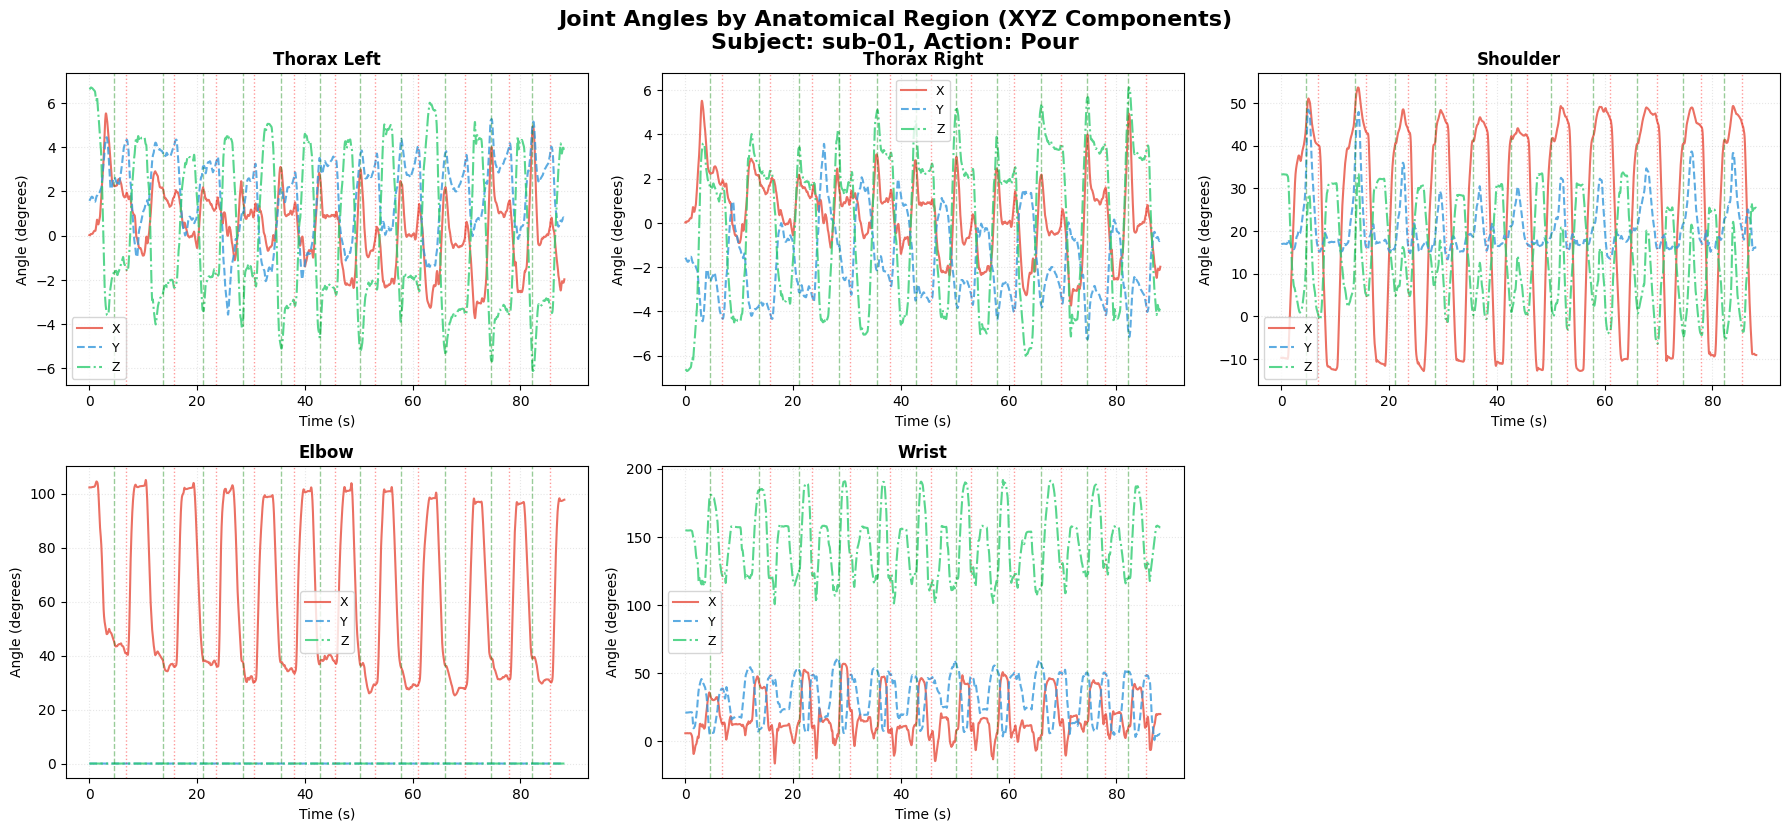


Visualization complete: 5 anatomical regions plotted
Color coding: X=#e74c3c, Y=#3498db, Z=#2ecc71
Cut markers: Green dashed = repetition start, Red dotted = repetition end


In [93]:
# Visualize joints grouped by anatomical region with XYZ components
print(f"Joint Angle Trajectories by Anatomical Region - {SELECTED_SUBJECT} performing {SELECTED_ACTION}")
print("=" * 70)

# Create subplots for each anatomical region
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
fig.suptitle(f'Joint Angles by Anatomical Region (XYZ Components)\nSubject: {SELECTED_SUBJECT}, Action: {SELECTED_ACTION}', 
             fontsize=16, fontweight='bold')

axes = axes.flatten()
component_styles = {'X': '-', 'Y': '--', 'Z': '-.'}

# Convert cut indices to time values if needed
if SHOW_CUT_MARKERS and cut_indices is not None:
    from utils.data_loading import convert_cut_indices_to_times
    cut_times = convert_cut_indices_to_times(time, cut_indices)
else:
    cut_times = None

plot_idx = 0
for region_name, joint_cols in joint_groups.items():
    if plot_idx >= len(axes):
        break
    
    ax = axes[plot_idx]
    
    # Plot each XYZ component for this anatomical region
    for col in joint_cols:
        # Extract component (X, Y, or Z)
        component = col.split('_')[-1]
        color = component_colors.get(component, 'black')
        style = component_styles.get(component, '-')
        
        ax.plot(time, joint_angles[col], label=f'{component}', 
               color=color, linestyle=style, linewidth=1.5, alpha=0.8)
    
    # Add cut markers if enabled
    if cut_times is not None:
        for i, cut in enumerate(cut_times):
            cut_color = 'green' if i % 2 == 0 else 'red'
            cut_style = '--' if i % 2 == 0 else ':'
            ax.axvline(x=cut, color=cut_color, linestyle=cut_style, 
                      alpha=0.4, linewidth=1.0)
    
    # Format subplot
    ax.set_title(f'{region_name.replace("_", " ")}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time (s)', fontsize=10)
    ax.set_ylabel('Angle (degrees)', fontsize=10)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3, linestyle=':')
    
    plot_idx += 1

# Hide unused subplots
for i in range(plot_idx, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\nVisualization complete: {plot_idx} anatomical regions plotted")
print(f"Color coding: X={component_colors['X']}, Y={component_colors['Y']}, Z={component_colors['Z']}")
if cut_times is not None:
    print(f"Cut markers: Green dashed = repetition start, Red dotted = repetition end")


Component-wise Comparison - sub-01 performing Pour


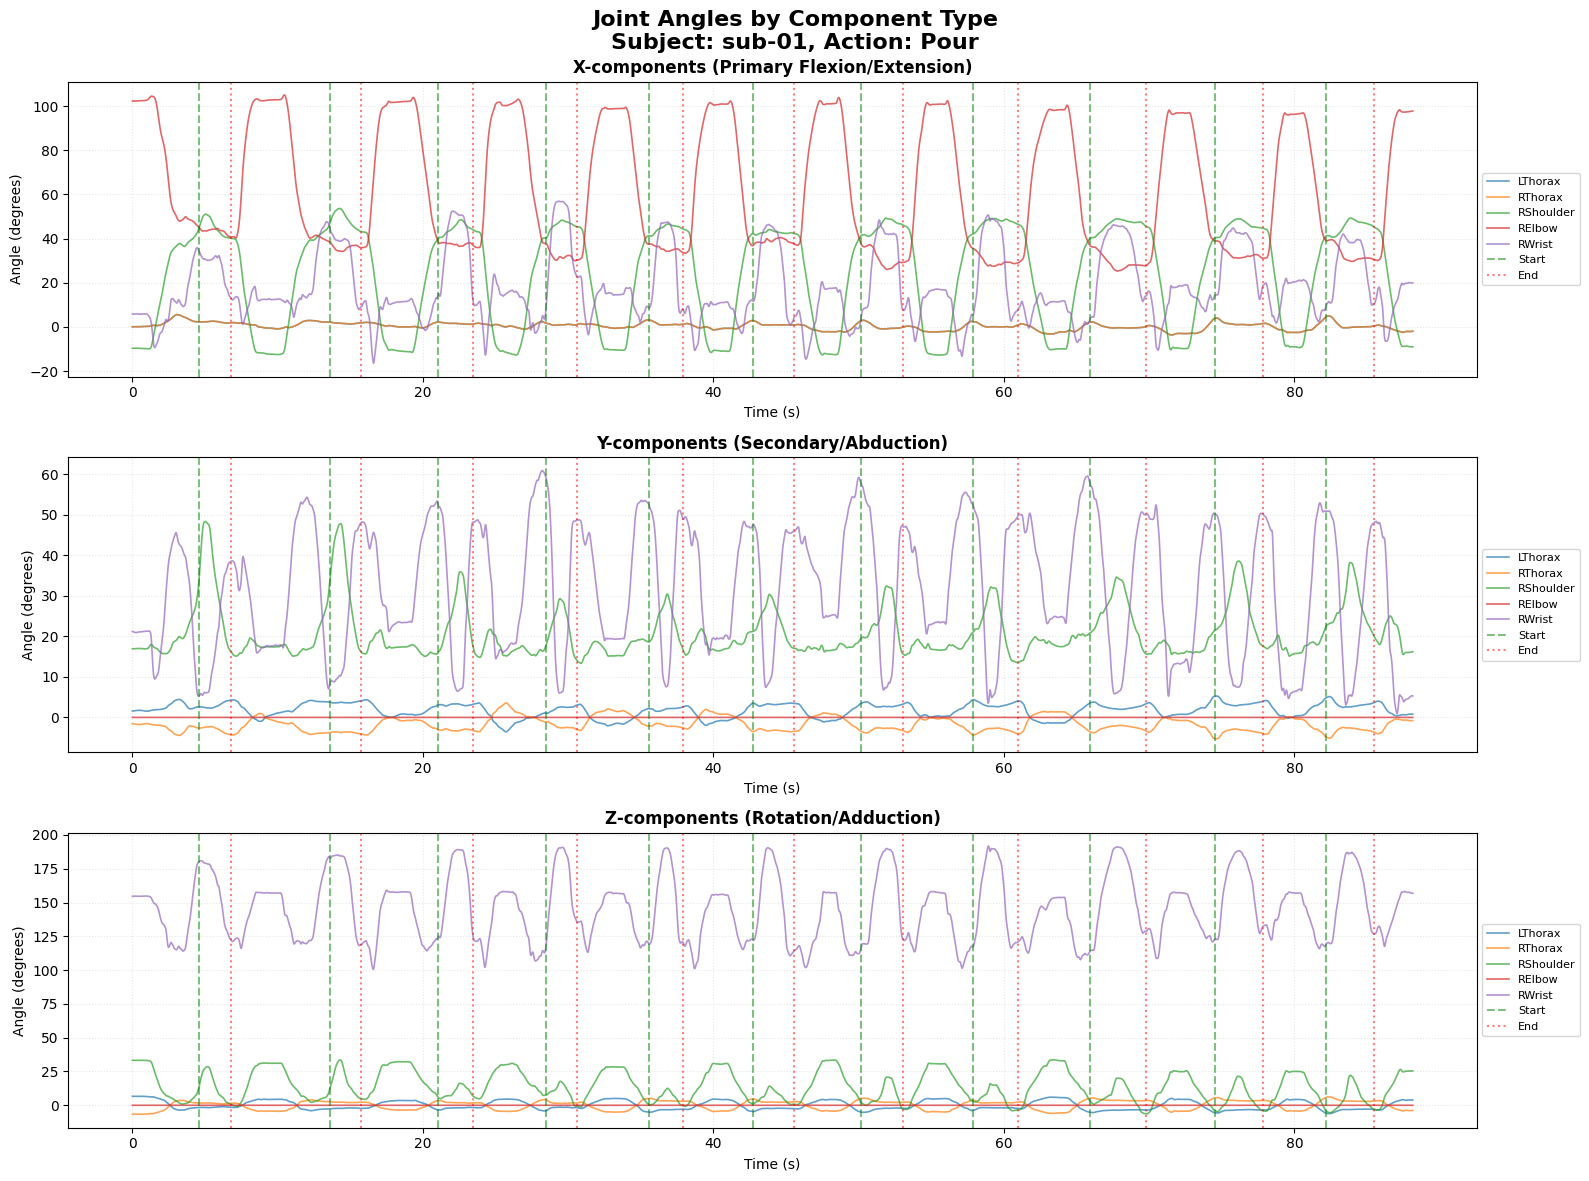


✓ Showing 11 repetition boundaries
  Green dashed lines = repetition start
  Red dotted lines = repetition end


In [94]:
# Alternative view: Plot all components of the same type together
print(f"\nComponent-wise Comparison - {SELECTED_SUBJECT} performing {SELECTED_ACTION}")
print("=" * 70)

fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle(f'Joint Angles by Component Type\nSubject: {SELECTED_SUBJECT}, Action: {SELECTED_ACTION}', 
             fontsize=16, fontweight='bold')

component_types = ['X', 'Y', 'Z']
component_labels = {
    'X': 'X-components (Primary Flexion/Extension)',
    'Y': 'Y-components (Secondary/Abduction)',
    'Z': 'Z-components (Rotation/Adduction)'
}

# Convert cut indices to time values if needed
if SHOW_CUT_MARKERS and cut_indices is not None:
    from utils.data_loading import convert_cut_indices_to_times
    cut_times = convert_cut_indices_to_times(time, cut_indices)
else:
    cut_times = None

for idx, component in enumerate(component_types):
    ax = axes[idx]
    
    # Plot all joints with this component
    for col in joint_angles.columns:
        if col.endswith(f'_{component}'):
            # Create simplified label
            label = col.replace('_X', '').replace('_Y', '').replace('_Z', '')
            ax.plot(time, joint_angles[col], label=label, linewidth=1.2, alpha=0.7)
    
    # Add cut markers if enabled
    if cut_times is not None:
        for i, cut in enumerate(cut_times):
            cut_color = 'green' if i % 2 == 0 else 'red'
            cut_style = '--' if i % 2 == 0 else ':'
            # Only add label for first occurrence
            label = 'Start' if i == 0 else ('End' if i == 1 else None)
            ax.axvline(x=cut, color=cut_color, linestyle=cut_style, 
                      alpha=0.5, linewidth=1.5, label=label)
    
    ax.set_title(component_labels[component], fontsize=12, fontweight='bold')
    ax.set_xlabel('Time (s)', fontsize=10)
    ax.set_ylabel('Angle (degrees)', fontsize=10)
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8, ncol=1)
    ax.grid(True, alpha=0.3, linestyle=':')

plt.tight_layout()
plt.show()

if cut_times is not None:
    print(f"\n✓ Showing {len(cut_times)//2} repetition boundaries")
    print("  Green dashed lines = repetition start")
    print("  Red dotted lines = repetition end")


Joint Angle Correlation Heatmap - sub-01 performing Pour


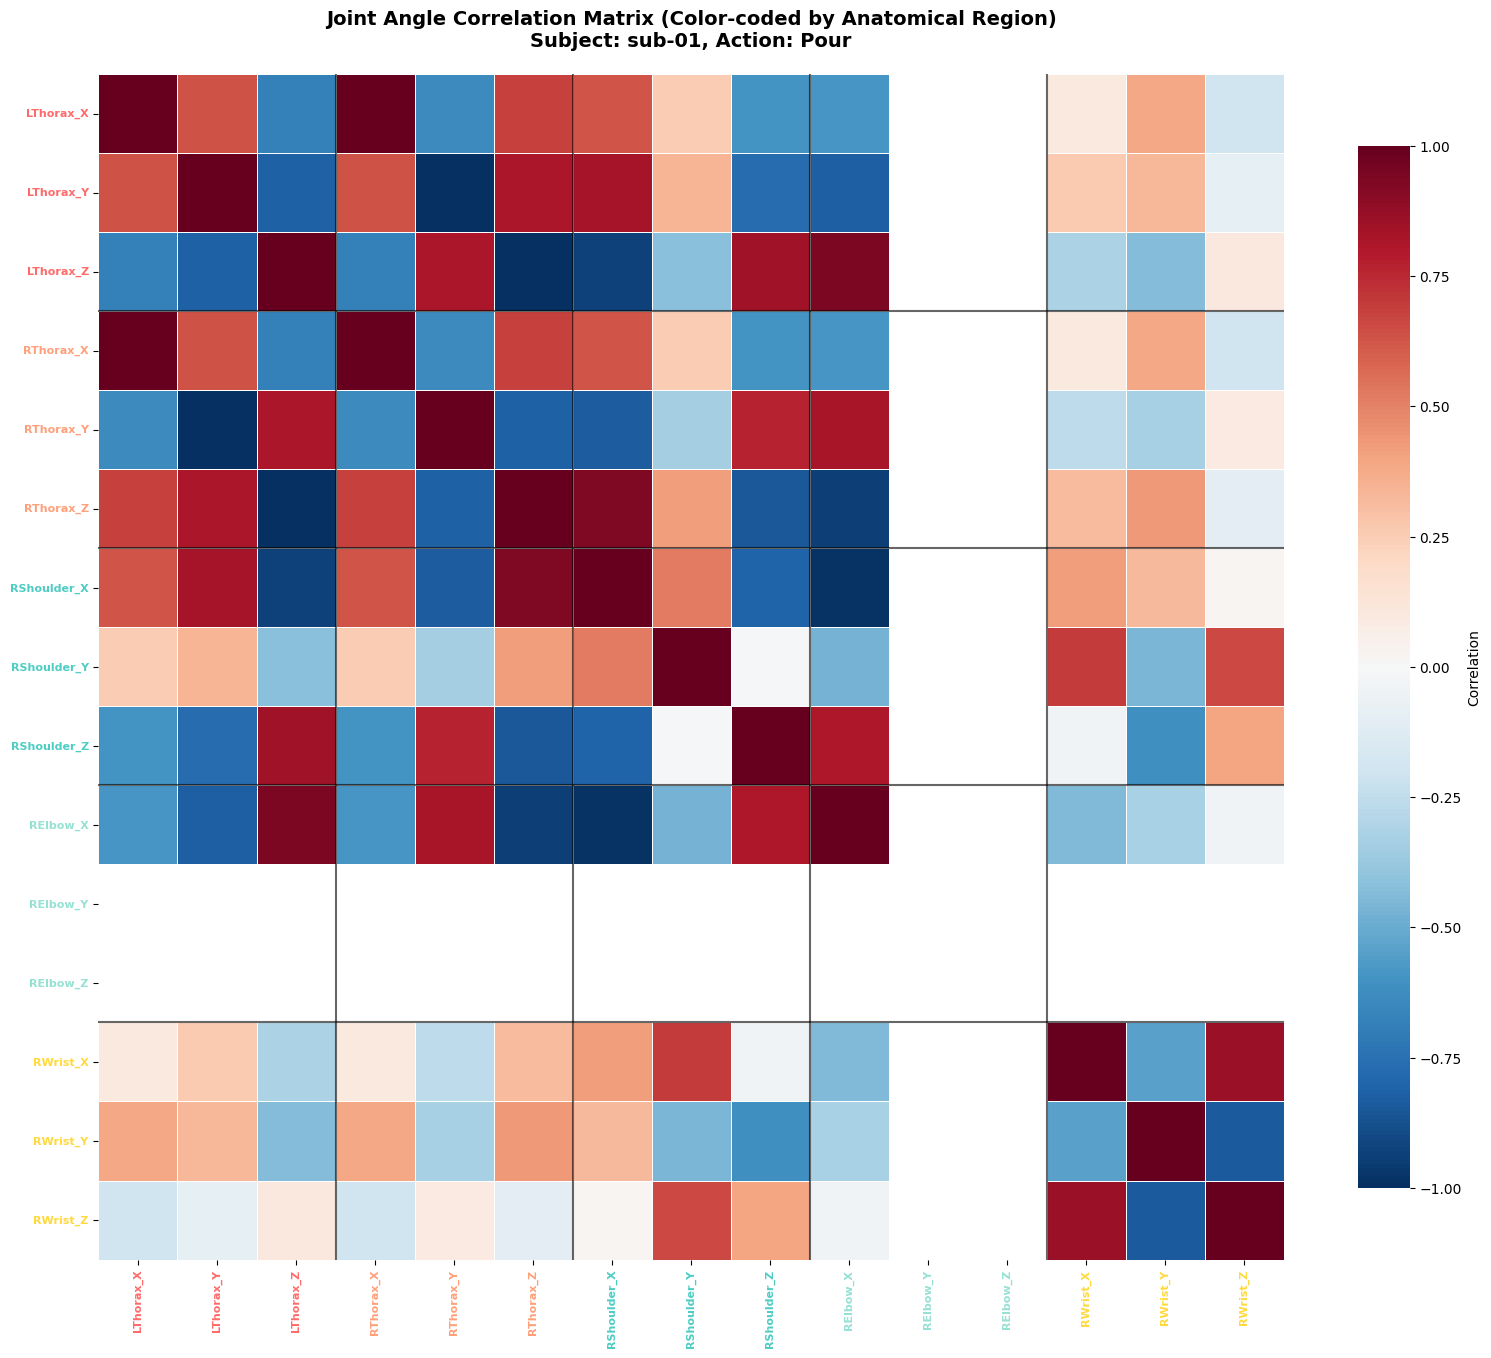


Anatomical Region Color Legend:
--------------------------------------------------
Thorax Left          : #FF6B6B
Thorax Right         : #FFA07A
Shoulder             : #4ECDC4
Elbow                : #95E1D3
Wrist                : #FFD93D
Index                : #6C5CE7
Middle               : #A29BFE
Ring                 : #FD79A8
Pinky                : #FDCB6E
Thumb STT            : #74B9FF
Thumb MCP            : #0984E3

Highly Correlated Joint Pairs (|r| > 0.7): 24 found

Top 5 correlations:
  LThorax_X       ↔ RThorax_X      :  1.000 (positive)
  LThorax_Y       ↔ RThorax_Y      : -1.000 (negative)
  LThorax_Z       ↔ RThorax_Z      : -1.000 (negative)
  RShoulder_X     ↔ RElbow_X       : -0.987 (negative)
  LThorax_Z       ↔ RElbow_X       :  0.942 (positive)

Correlation heatmap shows relationships between all joint channels
XYZ components of the same joint share the same color in labels
Black lines separate different anatomical regions


In [95]:
# Correlation heatmap with color-coded labels for XYZ components
print(f"\nJoint Angle Correlation Heatmap - {SELECTED_SUBJECT} performing {SELECTED_ACTION}")
print("=" * 70)

# Calculate correlation matrix using pandas built-in
correlation_matrix = joint_angles.corr()

fig, ax = plt.subplots(figsize=(16, 14))

# Create heatmap
sns.heatmap(correlation_matrix, cmap='RdBu_r', center=0, 
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8, 'label': 'Correlation'})

# Create color-coded tick labels using utility functions
joint_labels = []
joint_colors_list = []

for col in joint_angles.columns:
    # Find which region this joint belongs to
    region = None
    for region_name, joints in joint_groups.items():
        if col in joints:
            region = region_name
            break
    
    # Get color for this region from utility function
    color = region_colors.get(region, 'black')
    joint_labels.append(col)
    joint_colors_list.append(color)

# Set tick labels with colors
ax.set_xticks(np.arange(len(joint_labels)) + 0.5)
ax.set_yticks(np.arange(len(joint_labels)) + 0.5)
ax.set_xticklabels(joint_labels, rotation=90, fontsize=8)
ax.set_yticklabels(joint_labels, fontsize=8)

# Color the tick labels
for i, (xtick, ytick) in enumerate(zip(ax.get_xticklabels(), ax.get_yticklabels())):
    xtick.set_color(joint_colors_list[i])
    ytick.set_color(joint_colors_list[i])
    xtick.set_weight('bold')
    ytick.set_weight('bold')

ax.set_title(f'Joint Angle Correlation Matrix (Color-coded by Anatomical Region)\nSubject: {SELECTED_SUBJECT}, Action: {SELECTED_ACTION}', 
             fontsize=14, fontweight='bold', pad=20)

# Add grid lines to separate anatomical regions
cumsum = 0
for region_name, joint_cols in joint_groups.items():
    cumsum += len(joint_cols)
    if cumsum < len(joint_angles.columns):
        ax.axhline(y=cumsum, color='black', linestyle='-', linewidth=1.5, alpha=0.6)
        ax.axvline(x=cumsum, color='black', linestyle='-', linewidth=1.5, alpha=0.6)

plt.tight_layout()
plt.show()

# Use utility function to find highly correlated pairs
highly_correlated = find_highly_correlated_pairs(correlation_matrix, threshold=0.7)

# Display results
print("\nAnatomical Region Color Legend:")
print("-" * 50)
for region_name, color in region_colors.items():
    region_display = region_name.replace('_', ' ')
    print(f"{region_display:<20} : {color}")

print(f"\nHighly Correlated Joint Pairs (|r| > 0.7): {len(highly_correlated)} found")
if highly_correlated:
    print("\nTop 5 correlations:")
    for joint1, joint2, corr in highly_correlated[:5]:
        direction = "positive" if corr > 0 else "negative"
        print(f"  {joint1:<15} ↔ {joint2:<15}: {corr:>6.3f} ({direction})")

print("\nCorrelation heatmap shows relationships between all joint channels")
print("XYZ components of the same joint share the same color in labels")
print("Black lines separate different anatomical regions")

In [96]:
# Analyze movement phases using utility functions
print("Movement Phase Analysis:")
print("=" * 50)

# Calculate kinematic derivatives using utility functions
joint_velocities = calculate_velocity(time, joint_angles)
joint_accelerations = calculate_acceleration(time, joint_angles)

# Detect movement onset using utility function
onset_idx, offset_idx = detect_movement_onset(joint_velocities, threshold_factor=0.5)

movement_start_time = time[onset_idx]
movement_end_time = time[offset_idx]
print(f"Movement Duration: {movement_end_time - movement_start_time:.2f} seconds")
print(f"Movement Start: {movement_start_time:.2f}s, End: {movement_end_time:.2f}s")

# Analyze peak velocities
print(f"\nTop 5 Peak Velocities:")
peak_velocities = joint_velocities.abs().max()
top_5 = peak_velocities.nlargest(5)
for joint_name, peak_vel in top_5.items():
    # Remove '_vel' suffix from column name
    original_joint = joint_name.replace('_vel', '')
    print(f"{original_joint:<20}: {peak_vel:>8.2f} °/s")

# Calculate movement smoothness using utility function
smoothness = calculate_movement_smoothness(time, joint_angles)

print(f"\nMovement Smoothness (Normalized Jerk):")
print(f"Smoothest joint: {smoothness.idxmin()} (jerk: {smoothness.min():.4f})")
print(f"Least smooth joint: {smoothness.idxmax()} (jerk: {smoothness.max():.4f})")
print(f"Average smoothness: {smoothness.mean():.4f}")

# Show top 5 smoothest and roughest
print(f"\nTop 5 Smoothest Joints:")
for joint_name, jerk_val in smoothness.nsmallest(5).items():
    print(f"  {joint_name:<20}: {jerk_val:.4f}")

print(f"\nTop 5 Least Smooth Joints:")
for joint_name, jerk_val in smoothness.nlargest(5).items():
    print(f"  {joint_name:<20}: {jerk_val:.4f}")

Movement Phase Analysis:
Movement Duration: 86.18 seconds
Movement Start: 1.23s, End: 87.41s

Top 5 Peak Velocities:
RWrist_Z            :   195.11 °/s
RWrist_X            :   153.98 °/s
RElbow_X            :   128.58 °/s
RWrist_Y            :   117.57 °/s
RShoulder_X         :    69.79 °/s

Movement Smoothness (Normalized Jerk):
Smoothest joint: RElbow_Y (jerk: 0.0000)
Least smooth joint: RWrist_Z (jerk: 7643.8999)
Average smoothness: 1777.3168

Top 5 Smoothest Joints:
  RElbow_Y            : 0.0000
  RElbow_Z            : 0.0000
  LThorax_Y           : 280.0502
  RThorax_Y           : 280.0502
  LThorax_Z           : 360.3117

Top 5 Least Smooth Joints:
  RWrist_Z            : 7643.8999
  RWrist_X            : 6297.4187
  RWrist_Y            : 4978.1923
  RShoulder_Z         : 2083.2777
  RElbow_X            : 1487.5292


## Joint Coordination Analysis

Examine how different joints coordinate during the movement task.

In [97]:
# Analyze joint coordination using utility function
from reachgrasp importanalyze_joint_coordination

print("Joint Coordination Analysis:")
print("=" * 70)

# Analyze coordination with time lags
print("\nAnalyzing joint coordination (this may take a moment)...")
coord_results = analyze_joint_coordination(
    joint_angles, 
    time, 
    max_lag=50,  # 0.5 seconds at 100 Hz
    min_correlation=0.5
)

print(f"\nFound {len(coord_results)} coordinated joint pairs (|r| ≥ 0.5)")

if coord_results:
    print("\nTop 10 Coordinated Joint Pairs (with time lags):")
    print(f"{'Joint 1':<20} {'Joint 2':<20} {'Correlation':>12} {'Lag':>8} {'Lead/Lag'}")
    print("-" * 80)
    
    for result in coord_results[:10]:
        if result['lag'] > 0:
            direction = f"{result['joint1'][:8]}→{result['joint2'][:8]}"
            lag_desc = f"+{result['lag_time']:.3f}s"
        elif result['lag'] < 0:
            direction = f"{result['joint2'][:8]}→{result['joint1'][:8]}"
            lag_desc = f"{result['lag_time']:.3f}s"
        else:
            direction = "synchronized"
            lag_desc = "0.000s"
        
        print(f"{result['joint1']:<20} ↔ {result['joint2']:<20} "
              f"{result['correlation']:>11.3f} {lag_desc:>8} {direction}")
    
    # Summary statistics
    avg_correlation = np.mean([abs(r['correlation']) for r in coord_results])
    print(f"\n{'='*80}")
    print(f"Average coordination strength: {avg_correlation:.3f}")
    
    # Synchrony vs. lagged coordination
    synchronized = sum(1 for r in coord_results if r['lag'] == 0)
    lagged = len(coord_results) - synchronized
    print(f"Synchronized pairs: {synchronized} ({synchronized/len(coord_results)*100:.1f}%)")
    print(f"Lagged pairs: {lagged} ({lagged/len(coord_results)*100:.1f}%)")
else:
    print("No significant coordination found with current threshold")

Joint Coordination Analysis:

Analyzing joint coordination (this may take a moment)...

Found 43 coordinated joint pairs (|r| ≥ 0.5)

Top 10 Coordinated Joint Pairs (with time lags):
Joint 1              Joint 2               Correlation      Lag Lead/Lag
--------------------------------------------------------------------------------
LThorax_Z            ↔ RThorax_Z                 -1.000   0.000s synchronized
LThorax_Y            ↔ RThorax_Y                 -1.000   0.000s synchronized
LThorax_X            ↔ RThorax_X                  1.000   0.000s synchronized
RShoulder_X          ↔ RElbow_X                  -0.987   0.000s synchronized
LThorax_Z            ↔ RElbow_X                   0.942   0.000s synchronized
RThorax_Z            ↔ RElbow_X                  -0.942   0.000s synchronized
LThorax_Z            ↔ RShoulder_X               -0.937   0.000s synchronized
RThorax_Z            ↔ RShoulder_X                0.937   0.000s synchronized
RWrist_X             ↔ RWrist_Z        

## Comparative Analysis

Compare joint kinematics across different subjects or actions by modifying the global variables.

In [98]:
# Comparative analysis setup
print("Comparative Analysis Setup:")
print("=" * 50)
print("To compare different subjects or actions, modify the global variables at the top:")
print()
print("# Current configuration:")
print(f"SELECTED_SUBJECT = '{SELECTED_SUBJECT}'")
print(f"SELECTED_ACTION = '{SELECTED_ACTION}'")
print()
print("# Example comparisons you can try:")
print("# 1. Different actions with same subject:")
print("SELECTED_SUBJECT = 'sub-01'")
print("SELECTED_ACTION = 'HO'  # Hand opening")
print("# or")
print("SELECTED_ACTION = 'HC'  # Hand closing")
print()
print("# 2. Same action with different subjects:")
print("SELECTED_SUBJECT = 'sub-02'")
print("SELECTED_ACTION = 'Cyl'")
print("# or")
print("SELECTED_SUBJECT = 'sub-03'")
print()
print("# 3. Different grasp types:")
print("SELECTED_ACTION = 'Sph'  # Spherical grasp")
print("# or")
print("SELECTED_ACTION = 'Trid'  # Triangular grasp")
print()
print("After changing variables, re-run all cells from 'Data Loading' section.")

# Quick comparison function using utility functions
def compare_joint_kinematics(subject1, action1, subject2, action2, joint_name='RElbow_X'):
    """
    Compare joint kinematics between two subject-action combinations.

    Parameters:
    - subject1, subject2: Subject IDs (e.g., 'sub-01')
    - action1, action2: Action names (e.g., 'Cyl')
    - joint_name: Joint name to compare (e.g., 'RElbow_X', 'RWrist_Y')
    """
    try:
        # Load first dataset using utility function
        time1, joints1 = load_joint_angles_with_labels(subject1, action1)
        
        # Load second dataset using utility function
        time2, joints2 = load_joint_angles_with_labels(subject2, action2)
        
        # Check if joint exists
        if joint_name not in joints1.columns or joint_name not in joints2.columns:
            print(f"Joint '{joint_name}' not found. Available joints:")
            print(joints1.columns.tolist())
            return
        
        joint1 = joints1[joint_name]
        joint2 = joints2[joint_name]

        # Plot comparison
        plt.figure(figsize=(12, 6))
        plt.plot(time1, joint1, 'b-', label=f'{subject1} - {action1}', linewidth=2)
        plt.plot(time2, joint2, 'r--', label=f'{subject2} - {action2}', linewidth=2)
        plt.title(f'{joint_name} Comparison')
        plt.xlabel('Time (s)')
        plt.ylabel('Angle (degrees)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

        # Print statistics
        print(f"{joint_name} Statistics:")
        print(f"{subject1}-{action1}: Range={joint1.max()-joint1.min():.1f}°, "
              f"Mean={joint1.mean():.1f}°, Std={joint1.std():.1f}°")
        print(f"{subject2}-{action2}: Range={joint2.max()-joint2.min():.1f}°, "
              f"Mean={joint2.mean():.1f}°, Std={joint2.std():.1f}°")

    except FileNotFoundError as e:
        print(f"Error loading data: {e}")
    except Exception as e:
        print(f"Error: {e}")

print("\nQuick Comparison Function Available:")
print("Use compare_joint_kinematics(subject1, action1, subject2, action2, joint_name)")
print("Example: compare_joint_kinematics('sub-01', 'Cyl', 'sub-01', 'Sph', 'RElbow_X')")

Comparative Analysis Setup:
To compare different subjects or actions, modify the global variables at the top:

# Current configuration:
SELECTED_SUBJECT = 'sub-01'
SELECTED_ACTION = 'Pour'

# Example comparisons you can try:
# 1. Different actions with same subject:
SELECTED_SUBJECT = 'sub-01'
SELECTED_ACTION = 'HO'  # Hand opening
# or
SELECTED_ACTION = 'HC'  # Hand closing

# 2. Same action with different subjects:
SELECTED_SUBJECT = 'sub-02'
SELECTED_ACTION = 'Cyl'
# or
SELECTED_SUBJECT = 'sub-03'

# 3. Different grasp types:
SELECTED_ACTION = 'Sph'  # Spherical grasp
# or
SELECTED_ACTION = 'Trid'  # Triangular grasp

After changing variables, re-run all cells from 'Data Loading' section.

Quick Comparison Function Available:
Use compare_joint_kinematics(subject1, action1, subject2, action2, joint_name)
Example: compare_joint_kinematics('sub-01', 'Cyl', 'sub-01', 'Sph', 'RElbow_X')


## Summary

This notebook provides comprehensive joint kinematics analysis for the ReachGrasp dataset.

### Key Features:
- **Configurable Analysis**: Change `SELECTED_SUBJECT`, `SELECTED_ACTION`, and `JOINT_FILTER` for different analyses
- **Flexible Joint Filtering**: Focus on arm joints, hand joints, all joints, or custom selection
- **Multiple Visualization Modes**: Grid layout and overlapping plots for different perspectives
- **Movement Phase Analysis**: Velocity, acceleration, and jerk analysis using utility functions
- **Coordination Analysis**: Joint correlation and time-lagged synchronization measures
- **Comparative Tools**: Built-in functions for cross-subject/action comparisons
- **Utility Functions**: Leverages comprehensive utils library for clean, reusable code

### Current Configuration:
- **Subject**: `SELECTED_SUBJECT`
- **Action**: `SELECTED_ACTION`
- **Joint Filter**: `JOINT_FILTER` (options: 'all', 'arm', 'hand', or custom list)
  - **'all'**: Complete upper limb (31 joints)
  - **'arm'**: Proximal joints + Wrist - Thorax, Shoulder, Elbow, Wrist (15 joints)
  - **'hand'**: Distal joints - Fingers, Thumb (16 joints)
  - **Custom**: Specify exact joints, e.g., `['RElbow_X', 'RWrist_Y', 'RIndex_X']`

### Usage Tips:
1. **Change Configuration**: Modify global variables (`SELECTED_SUBJECT`, `SELECTED_ACTION`, `JOINT_FILTER`) at the top
2. **Re-run Analysis**: After changing variables, re-run cells from "Data Loading" section onward
3. **Filter Focus**: 
   - Use `JOINT_FILTER='arm'` for reaching movements (includes wrist for end-effector position)
   - Use `JOINT_FILTER='hand'` for pure hand/finger grasping analysis
   - Use custom list for biomechanical studies of specific joint combinations
4. **Quick Comparisons**: Use `compare_joint_kinematics()` function for cross-condition analyses
5. **Coordination Insights**: Joint coordination analysis reveals lead/lag relationships

### Filter Examples:
```python
# Arm movements (reaching, pointing)
JOINT_FILTER = 'arm'

# Hand movements (grasping, manipulation)
JOINT_FILTER = 'hand'

# Specific biomechanical analysis
JOINT_FILTER = ['RElbow_X', 'RWrist_X', 'RIndex_X']  # Flexion chain

# All components of wrist and elbow
JOINT_FILTER = ['RElbow_X', 'RElbow_Y', 'RElbow_Z', 
                'RWrist_X', 'RWrist_Y', 'RWrist_Z']
```

### Next Steps:
- Compare arm vs. hand coordination patterns across different tasks
- Analyze temporal relationships between proximal and distal joint movements
- Machine learning classification using filtered joint subsets
- Task-specific biomechanical modeling (reaching vs. grasping)
- Custom joint selection for clinical or research-specific analyses